In [ ]:

from osa import OSA
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
from wsapi import * 
import math

#saving to latex pdf
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.preamble": r"\usepackage{amsmath}",
})

def nearest_tenth(x):
    return math.ceil(x * 10) / 10

def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    # Step 6: Apply profile to waveshaper    
    wsh.apply_profile(new_profile)


test


In [97]:
SPEED_OF_LIGHT = 299792458/1
n_comblines = 65

# separation_comblines = 0.2
combline_freq_separation = 25 #GHZ
initial_wl = 1549.906
# initial_wl = 1543.795
initial_freq = SPEED_OF_LIGHT/initial_wl
freqs = np.arange(initial_freq, initial_freq - n_comblines * combline_freq_separation, -combline_freq_separation)

# comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
comblines = SPEED_OF_LIGHT/freqs
#get array of expected SHG wavelengths
target_freqs = np.sort(np.unique(np.add.outer(freqs, freqs)))[::-1]
targets = SPEED_OF_LIGHT/target_freqs# + 0.014e-9
print(f"combline wavelenths: {comblines}")
print(f"SHG wavelengths: {targets}")

combline wavelenths: [1549.906      1550.10634853 1550.30674886 1550.50720102 1550.70770502
 1550.90826088 1551.10886862 1551.30952827 1551.51023984 1551.71100336
 1551.91181884 1552.1126863  1552.31360577 1552.51457726 1552.7156008
 1552.9166764  1553.11780409 1553.31898388 1553.52021579 1553.72149986
 1553.92283609 1554.1242245  1554.32566512 1554.52715797 1554.72870307
 1554.93030043 1555.13195008 1555.33365204 1555.53540633 1555.73721297
 1555.93907198 1556.14098337 1556.34294718 1556.54496342 1556.74703211
 1556.94915327 1557.15132692 1557.35355308 1557.55583178 1557.75816303
 1557.96054685 1558.16298327 1558.3654723  1558.56801397 1558.7706083
 1558.9732553  1559.17595499 1559.37870741 1559.58151256 1559.78437047
 1559.98728116 1560.19024465 1560.39326096 1560.59633011 1560.79945212
 1561.00262702 1561.20585482 1561.40913554 1561.6124692  1561.81585583
 1562.01929545 1562.22278807 1562.42633372 1562.62993242 1562.83358418]
SHG wavelengths: [774.953      775.0030839  775.05317426 

Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


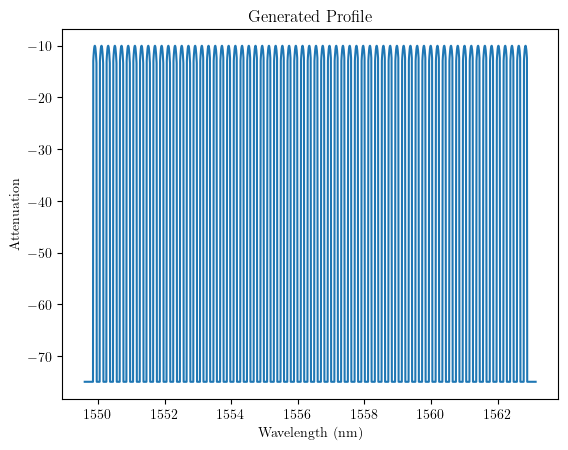

Applying profile...   success


In [98]:
create_connect_waveshaper()
peaks = np.ones(n_comblines)*.1
# peaks[1:-1]=0
apply_waveshaper_profile(comblines, peaks, np.zeros(n_comblines), np.ones(n_comblines), plot = True, delta_l=0.05, sigma=0.005)


In [83]:
print(peaks)

[0.58872459 0.53072571 0.51065507 0.48183567 0.42897503 0.41432025
 0.34564041 0.37200063 0.32102446 0.3503073  0.28518368 0.29911132
 0.25327902 0.2570597  0.23411328 0.2233487  0.21531948 0.21660223
 0.18840847 0.19406005 0.16915738 0.1660687  0.149536   0.14484453
 0.13431976 0.12612066 0.12543391 0.10839038 0.1124533  0.09739331
 0.09896887 0.08791399 0.08695773 0.07774014 0.07652863 0.06293043
 0.12122771 0.05874065 0.0799     0.08741619 0.08741904 0.09464178
 0.09139014 0.11249416 0.10874643 0.12250339 0.13827639 0.15096866
 0.17099095 0.18776243 0.20445757 0.23729074 0.25650508 0.27864394
 0.3075895  0.34121236 0.39050898 0.40265992 0.48850753 0.54443987
 0.58856151 0.66770916 0.82371701 0.90995444 1.        ]


In [100]:
# Connect OSA directly to waveshaper output (NOT SHG)
# Measures relative combline powers, so we can adjust peaks to get them even
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
peaks = np.ones(n_comblines)
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)
relative_combline_intensities = np.ones(n_comblines)
N_revisions=5
for i in range(N_revisions+1):
    apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phases, channels, plot = False, delta_l=0.05, sigma=0.005)
    wavelengths, power = osa.perform_measurement_OSA((np.max(comblines)+np.min(comblines))/2, nearest_tenth((np.max(comblines)-np.min(comblines))*1.0), 5000, sensitivity = "high1", resolution = 0.02)
    combline_indices = [np.argmin(np.abs(wavelengths - combline*1e-9)) for combline in comblines]
    radius = (combline_indices[1] - combline_indices[0])//2

    combline_intensities = np.array([
        np.array(power)[max(0, i-radius):min(len(power), i+radius)-1].max()
        for i in combline_indices
    ])

    plt.plot(wavelengths, power)
    plt.scatter(np.array(wavelengths)[combline_indices], combline_intensities, color="red")
    plt.show()

    new_relative_intensities = relative_combline_intensities * combline_intensities
    new_relative_intensities /= np.min(new_relative_intensities)

    if i < 3:
        relative_combline_intensities = new_relative_intensities
    elif i < N_revisions:
        #past first 3 rounds, new measurements should have progressively less effect, to even out noise
        ratio = 1 / (i-1)
        relative_combline_intensities = ratio * new_relative_intensities + (1-ratio) * relative_combline_intensities

print(f"Relative combline intensities: {relative_combline_intensities}")

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
Applying profile...   success


KeyboardInterrupt: 

In [84]:
import time
start_time = time.time()

host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)

#record power by two metrics, can compare later
max_powers = np.empty((n_comblines, n_comblines))
avg_powers = np.empty((n_comblines, n_comblines))
cells_done=0
cells_total = n_comblines*(n_comblines+1)//2

for i in range(n_comblines):
    for j in range(n_comblines):
        if i > j:
            continue


        peaks = np.zeros(n_comblines)
        peaks[i] += 0.5    # when i==j we should allow the intensity of the single combline to be double
        peaks[j] += 0.5
        peaks /= relative_combline_intensities
        print(peaks)
        apply_waveshaper_profile(comblines, peaks, phases, channels, plot = False, delta_l=0.05, sigma=0.005)
        # wavelengths, power = osa.perform_measurement_OSA(targets[i+j], 0.1, 0.2, sensitivity="high1", resolution=0.02)
        # max_powers[i, j] = np.max(power)
        # avg_powers[i, j] = np.average(power)
        # max_powers[j, i] = np.max(power)
        # avg_powers[j, i] = np.average(power)
        time.sleep(1)
        cells_done += 1
        progress = cells_done/cells_total
        elapsed = time.time() - start_time

        print(f'({comblines[i]:.2f}, {comblines[j]:.2f}): max {max_powers[i, j]*1e3:.3f}uW, avg {avg_powers[i, j]*1e3:.3f}uW        ...{progress*100:.2f}%  ETR {elapsed * (1 - progress) / progress / 60:.1f}min')

# np.savez('phase_matching.npz', wavelengths=comblines, max_powers=max_powers, avg_powers=avg_powers)


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
[0.58872459 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
Applying profile...   success
(1549.91, 1549.91): max 0.000uW, avg 0.000uW        ...0.05%  ETR 68.5min
[0.29436229 0.26536285 0.         0.         0.         0.
 0.         0.   

KeyboardInterrupt: 

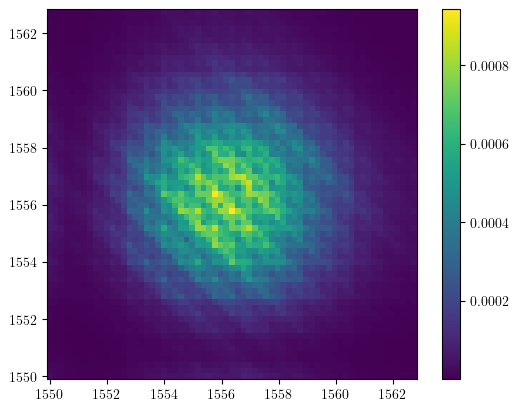

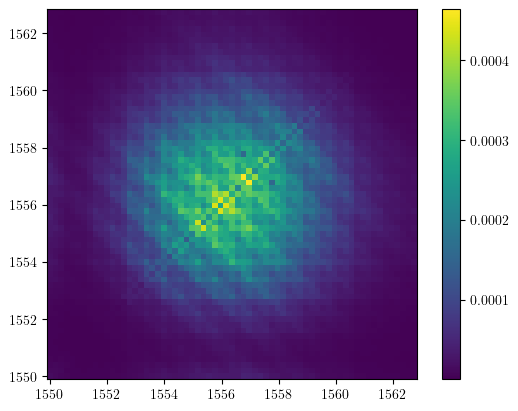

In [76]:
data = np.load('phase_matching.npz')
wls = data['wavelengths']
maxes = data['max_powers']
avges = data['avg_powers']

plt.imshow(maxes,
           origin='lower',
           extent=[wls.min(), wls.max(), wls.min(), wls.max()])
plt.colorbar()
plt.show()

plt.imshow(avges,
           origin='lower',
           extent=[wls.min(), wls.max(), wls.min(), wls.max()])
plt.colorbar()
plt.show()